# Arousal Prediction — v4 Pipeline

## Key findings from v3 → v4

| Observation | Fix |
|---|---|
| Arousal lag-1 autocorrelation = 0.80–0.94 across all pids | Add lag-1 & lag-2 sensor features |
| RF wins LOPO 8/11 pids (0.847 vs ensemble 0.885) | RF primary (60%) + LGB secondary (40%) |
| 7PF3 / CQ2G LOPO > 1.2 | Person-relative delta features (current − 30s baseline) |
| bvp_missing = 100% at 5s window | Extend BVP window to 10s |
| 100+ features on 1300 samples → noise | Feature selection: keep top-60 by RF importance |
| Class 1/5 still under-predicted | Boost their sample weight 2× (was 1.5×) |

In [1]:
!pip install pandas numpy scipy scikit-learn lightgbm imbalanced-learn matplotlib


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import welch
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
from imblearn.over_sampling import ADASYN, SMOTE
import matplotlib.pyplot as plt

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
DATA = '.'

train_labels = pd.read_csv(f'{DATA}/train-label.csv')
test_labels  = pd.read_csv(f'{DATA}/test-label.csv')

trainbvp   = pd.read_csv(f'{DATA}/train-bvp.csv')
traineda   = pd.read_csv(f'{DATA}/train-eda.csv')
traintemp  = pd.read_csv(f'{DATA}/train-temp.csv')
trainhr    = pd.read_csv(f'{DATA}/train-hr.csv')
trainibi   = pd.read_csv(f'{DATA}/train-ibi.csv')
trainbrain = pd.read_csv(f'{DATA}/train-brain.csv')
trainacc   = pd.read_csv(f'{DATA}/train-acc.csv')

testbvp    = pd.read_csv(f'{DATA}/test-bvp.csv')
testeda    = pd.read_csv(f'{DATA}/test-eda.csv')
testtemp   = pd.read_csv(f'{DATA}/test-temp.csv')
testhr     = pd.read_csv(f'{DATA}/test-hr.csv')
testibi    = pd.read_csv(f'{DATA}/test-ibi.csv')
testbrain  = pd.read_csv(f'{DATA}/test-brain.csv')
testacc    = pd.read_csv(f'{DATA}/test-acc.csv')

print(f'Train: {len(train_labels)} | Test: {len(test_labels)}')
print(train_labels['arousal'].value_counts().sort_index())

Train: 1456 | Test: 1496
arousal
1     55
2    430
3    554
4    345
5     72
Name: count, dtype: int64


## 2. Feature Helpers

In [4]:
WINDOW       = 5000
BVP_WINDOW   = 10000   # extended: was 5s (0% coverage)
BRAIN_WINDOW = 10000
IBI_WINDOW   = 20000   # extended: wider HRV window
BASELINE_W   = 30000   # 30s lookback for delta features

def assign_windows_forward(sensor_df, labels_df, window):
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid']==pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid']==pid].copy()
        if len(sen) == 0:
            continue
        lbl_ts = lbl['timestamp'].values
        bins = np.append(lbl_ts, lbl_ts[-1] + window)
        sen['label_ts'] = pd.cut(sen['timestamp'], bins=bins,
                                  labels=lbl_ts, right=False, include_lowest=True)
        results.append(sen.dropna(subset=['label_ts']))
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out

def assign_windows_lookback(sensor_df, labels_df, window):
    """For each label ts, grab sensor readings from [ts-window, ts)."""
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid']==pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid']==pid].copy()
        if len(sen) == 0:
            continue
        for ts in lbl['timestamp'].values:
            chunk = sen[(sen['timestamp'] >= ts - window) & (sen['timestamp'] < ts)].copy()
            if len(chunk) > 0:
                chunk['label_ts'] = ts
                chunk['pid'] = pid
                results.append(chunk)
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out

def safe_stats(vals, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return {f'{prefix}_{k}': np.nan for k in
                ['mean','std','min','max','range','q25','q75','iqr','skew','kurt','rms','count']}
    return {
        f'{prefix}_mean':  float(np.mean(a)),
        f'{prefix}_std':   float(np.std(a)) if len(a)>1 else 0.0,
        f'{prefix}_min':   float(np.min(a)),
        f'{prefix}_max':   float(np.max(a)),
        f'{prefix}_range': float(np.ptp(a)),
        f'{prefix}_q25':   float(np.percentile(a,25)),
        f'{prefix}_q75':   float(np.percentile(a,75)),
        f'{prefix}_iqr':   float(np.percentile(a,75)-np.percentile(a,25)),
        f'{prefix}_skew':  float(stats.skew(a)) if len(a)>2 else 0.0,
        f'{prefix}_kurt':  float(stats.kurtosis(a)) if len(a)>2 else 0.0,
        f'{prefix}_rms':   float(np.sqrt(np.mean(a**2))),
        f'{prefix}_count': float(len(a)),
    }

def spectral_features(vals, fs, prefix):
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) < 8:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}
    try:
        f, psd = welch(a, fs=fs, nperseg=min(len(a), 64))
        lf = np.trapz(psd[(f>=0.04)&(f<=0.15)], f[(f>=0.04)&(f<=0.15)])
        hf = np.trapz(psd[(f>=0.15)&(f<=0.40)], f[(f>=0.15)&(f<=0.40)])
        return {f'{prefix}_lf': float(lf), f'{prefix}_hf': float(hf),
                f'{prefix}_lf_hf': float(lf/(hf+1e-9))}
    except:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}

print('Helpers defined.')

Helpers defined.


## 3. Feature Extraction

In [5]:
def build_features(labels_df, bvp_df, eda_df, temp_df, hr_df, ibi_df, brain_df, acc_df):
    print('  Forward windows...')
    bvp_w   = assign_windows_forward(bvp_df,   labels_df, BVP_WINDOW)
    eda_w   = assign_windows_forward(eda_df,   labels_df, WINDOW)
    temp_w  = assign_windows_forward(temp_df,  labels_df, WINDOW)
    hr_w    = assign_windows_forward(hr_df,    labels_df, WINDOW)
    ibi_w   = assign_windows_forward(ibi_df,   labels_df, IBI_WINDOW)
    brain_w = assign_windows_forward(brain_df, labels_df, BRAIN_WINDOW)
    acc_w   = assign_windows_forward(acc_df,   labels_df, WINDOW)

    print('  Lookback baseline windows (30s)...')
    eda_b  = assign_windows_lookback(eda_df,  labels_df, BASELINE_W)
    temp_b = assign_windows_lookback(temp_df, labels_df, BASELINE_W)
    hr_b   = assign_windows_lookback(hr_df,   labels_df, BASELINE_W)
    acc_b  = assign_windows_lookback(acc_df,  labels_df, BASELINE_W)

    # BVP
    print('  BVP...')
    bvp_agg = bvp_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    bvp_feats = []
    for _, r in bvp_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'bvp'))
        d.update(spectral_features(r['value'], fs=64, prefix='bvp_spec'))
        a = np.array(r['value'])
        d['bvp_zcr'] = float(np.sum(np.diff(np.sign(np.diff(a)))!=0)/len(a)) if len(a)>2 else np.nan
        bvp_feats.append(d)
    bvp_feat_df = pd.DataFrame(bvp_feats)

    # EDA + delta
    print('  EDA...')
    eda_agg = eda_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    eda_b_mean = eda_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    eda_b_mean.columns = ['pid','label_ts','eda_baseline']
    eda_feats = []
    for _, r in eda_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'eda'))
        a = np.array(r['value'], dtype=float)
        if len(a) > 2:
            d['eda_slope'] = float(np.polyfit(np.arange(len(a)), a, 1)[0])
            d['eda_peaks'] = float(np.sum((np.diff(np.sign(np.diff(a))))<0))
        else:
            d['eda_slope'] = np.nan; d['eda_peaks'] = np.nan
        eda_feats.append(d)
    eda_feat_df = pd.DataFrame(eda_feats)
    eda_feat_df = eda_feat_df.merge(eda_b_mean, on=['pid','label_ts'], how='left')
    eda_feat_df['eda_delta'] = eda_feat_df['eda_mean'] - eda_feat_df['eda_baseline']

    # TEMP + delta
    print('  TEMP...')
    temp_feat_df = temp_w.groupby(['pid','label_ts'])['value'].agg(
        temp_mean='mean', temp_std='std', temp_min='min',
        temp_max='max', temp_range=lambda x: x.max()-x.min()).reset_index()
    temp_b_mean = temp_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    temp_b_mean.columns = ['pid','label_ts','temp_baseline']
    temp_feat_df = temp_feat_df.merge(temp_b_mean, on=['pid','label_ts'], how='left')
    temp_feat_df['temp_delta'] = temp_feat_df['temp_mean'] - temp_feat_df['temp_baseline']

    # HR + delta
    print('  HR...')
    hr_feat_df = hr_w.groupby(['pid','label_ts'])['value'].agg(
        hr_mean='mean', hr_std='std', hr_min='min',
        hr_max='max', hr_range=lambda x: x.max()-x.min()).reset_index()
    hr_b_mean = hr_b.groupby(['pid','label_ts'])['value'].mean().reset_index()
    hr_b_mean.columns = ['pid','label_ts','hr_baseline']
    hr_feat_df = hr_feat_df.merge(hr_b_mean, on=['pid','label_ts'], how='left')
    hr_feat_df['hr_delta'] = hr_feat_df['hr_mean'] - hr_feat_df['hr_baseline']

    # IBI + HRV
    print('  IBI/HRV...')
    ibi_agg = ibi_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    ibi_feats = []
    for _, r in ibi_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'ibi'))
        a = np.array(r['value'], dtype=float)
        a = a[~np.isnan(a)]
        if len(a) > 1:
            diffs = np.diff(a)
            d['ibi_rmssd'] = float(np.sqrt(np.mean(diffs**2)))
            d['ibi_sdnn']  = float(np.std(a))
            d['ibi_pnn50'] = float(np.mean(np.abs(diffs)>50))
        else:
            d['ibi_rmssd'] = np.nan; d['ibi_sdnn'] = np.nan; d['ibi_pnn50'] = np.nan
        d.update(spectral_features(r['value'], fs=4, prefix='ibi_spec'))
        ibi_feats.append(d)
    ibi_feat_df = pd.DataFrame(ibi_feats)

    # Brain
    print('  Brain...')
    brain_cols = ['delta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','middleGamma','theta']
    brain_agg = brain_w.groupby(['pid','label_ts'])[brain_cols].agg(['mean','std']).reset_index()
    brain_agg.columns = ['pid','label_ts'] + [f'brain_{c}_{s}' for c in brain_cols for s in ['mean','std']]
    brain_agg['brain_alpha_beta']  = ((brain_agg['brain_lowAlpha_mean']+brain_agg['brain_highAlpha_mean']) /
                                       (brain_agg['brain_lowBeta_mean']+brain_agg['brain_highBeta_mean']+1e-6))
    brain_agg['brain_theta_alpha'] = (brain_agg['brain_theta_mean'] /
                                       (brain_agg['brain_lowAlpha_mean']+brain_agg['brain_highAlpha_mean']+1e-6))
    brain_agg['brain_engagement']  = (brain_agg['brain_lowBeta_mean'] /
                                       (brain_agg['brain_theta_mean']+brain_agg['brain_lowAlpha_mean']+1e-6))

    # ACC + delta
    print('  ACC...')
    acc_w['mag'] = np.sqrt(acc_w['x']**2 + acc_w['y']**2 + acc_w['z']**2)
    acc_b['mag'] = np.sqrt(acc_b['x']**2 + acc_b['y']**2 + acc_b['z']**2)
    acc_agg   = acc_w.groupby(['pid','label_ts'])['mag'].apply(list).reset_index()
    acc_b_mean = acc_b.groupby(['pid','label_ts'])['mag'].mean().reset_index()
    acc_b_mean.columns = ['pid','label_ts','acc_baseline']
    acc_feats = []
    for _, r in acc_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['mag'], 'acc'))
        a = np.array(r['mag'], dtype=float)
        if len(a) > 2:
            jerk = np.diff(a)
            d['acc_jerk_mean'] = float(np.mean(np.abs(jerk)))
            d['acc_jerk_std']  = float(np.std(jerk))
        else:
            d['acc_jerk_mean'] = np.nan; d['acc_jerk_std'] = np.nan
        acc_feats.append(d)
    acc_feat_df = pd.DataFrame(acc_feats)
    acc_feat_df = acc_feat_df.merge(acc_b_mean, on=['pid','label_ts'], how='left')
    acc_feat_df['acc_delta'] = acc_feat_df['acc_mean'] - acc_feat_df['acc_baseline']

    # Merge
    print('  Merging...')
    base = labels_df[['id','pid','timestamp']].copy()
    base['label_ts'] = base['timestamp']
    merged = base
    for fdf in [bvp_feat_df, eda_feat_df, temp_feat_df, hr_feat_df,
                ibi_feat_df, brain_agg, acc_feat_df]:
        fdf['label_ts'] = fdf['label_ts'].astype(np.int64)
        merged = merged.merge(fdf, on=['pid','label_ts'], how='left')
    return merged.drop(columns=['label_ts'])

print('build_features() defined.')

build_features() defined.


In [6]:
print('Extracting TRAIN features (~4-6 min)...')
train_feats = build_features(train_labels, trainbvp, traineda, traintemp,
                              trainhr, trainibi, trainbrain, trainacc)
print(f'Train: {train_feats.shape}, missing: {train_feats.isnull().mean().mean():.2%}')

Extracting TRAIN features (~4-6 min)...
  Forward windows...
  Lookback baseline windows (30s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Train: (1456, 102), missing: 19.11%


In [7]:
print('Extracting TEST features (~4-6 min)...')
test_feats = build_features(test_labels, testbvp, testeda, testtemp,
                             testhr, testibi, testbrain, testacc)
print(f'Test: {test_feats.shape}, missing: {test_feats.isnull().mean().mean():.2%}')

Extracting TEST features (~4-6 min)...
  Forward windows...
  Lookback baseline windows (30s)...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI/HRV...
  Brain...
  ACC...
  Merging...
Test: (1496, 102), missing: 19.73%


## 4. Lag Features (key new addition — autocorr 0.80–0.94)

In [8]:
# ── FIXED: train_feats already has pid & timestamp from build_features ──
# No merge needed — removes the KeyError: 'pid' conflict

LAG_COLS = [
    'eda_mean','eda_min','eda_q75','eda_slope','eda_delta',
    'temp_mean','temp_min','temp_delta',
    'hr_mean','hr_std','hr_delta',
    'bvp_mean','bvp_skew',
    'acc_mean','acc_max','acc_delta',
    'ibi_rmssd','ibi_sdnn',
]

def add_lag_features(feat_df, lag_cols, lags=[1, 2]):
    """feat_df already contains pid + timestamp from build_features.
    No re-merge needed — that was causing the KeyError.
    """
    parts = []
    for pid in feat_df['pid'].unique():
        sub = feat_df[feat_df['pid'] == pid].sort_values('timestamp').copy()
        for lag in lags:
            for col in lag_cols:
                if col in sub.columns:
                    sub[f'{col}_lag{lag}'] = sub[col].shift(lag)
        parts.append(sub)
    return pd.concat(parts).sort_values('id').reset_index(drop=True)

print('Adding lag features to train...')
train_w_lags = add_lag_features(train_feats, LAG_COLS)
print('Adding lag features to test...')
test_w_lags  = add_lag_features(test_feats,  LAG_COLS)

new_cols = [f'{c}_lag{l}' for c in LAG_COLS for l in [1, 2]]
print(f'Added {len(new_cols)} lag columns. Train shape: {train_w_lags.shape}')

Adding lag features to train...
Adding lag features to test...
Added 36 lag columns. Train shape: (1456, 138)


## 5. Missing Indicators + Imputation

In [9]:
# OLD (causes same issue):
#train_df = train_w_lags.merge(train_labels[['id','arousal']], on='id', how='left')

# NEW (train_w_lags doesn't have arousal yet, merge only arousal):
train_df = train_w_lags.merge(train_labels[['id','arousal']], on='id', how='left')
test_df  = test_w_lags.copy()

feat_cols = [c for c in train_df.columns if c not in ['id','pid','timestamp','arousal']]
print(f'Feature count before selection: {len(feat_cols)}')

sensor_groups = {
    'bvp':   [c for c in feat_cols if c.startswith('bvp')],
    'eda':   [c for c in feat_cols if c.startswith('eda')],
    'temp':  [c for c in feat_cols if c.startswith('temp')],
    'hr':    [c for c in feat_cols if c.startswith('hr')],
    'ibi':   [c for c in feat_cols if c.startswith('ibi')],
    'brain': [c for c in feat_cols if c.startswith('brain')],
    'acc':   [c for c in feat_cols if c.startswith('acc')],
}
for grp, cols in sensor_groups.items():
    if cols:
        ind = f'{grp}_missing'
        train_df[ind] = train_df[cols].isnull().any(axis=1).astype(int)
        test_df[ind]  = test_df[cols].isnull().any(axis=1).astype(int)

feat_cols = [c for c in train_df.columns if c not in ['id','pid','timestamp','arousal']]
indicator_cols = [f'{g}_missing' for g in sensor_groups]

def impute_by_pid(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(df.groupby('pid')[cols].transform('median'))
    df[cols] = df[cols].fillna(df[cols].median())
    return df

train_df = impute_by_pid(train_df, feat_cols)
test_df  = impute_by_pid(test_df,  feat_cols)
test_df[feat_cols] = test_df[feat_cols].fillna(train_df[feat_cols].median())

print(f'Total feature count (with lags + indicators): {len(feat_cols)}')
print(f'Train NaN: {train_df[feat_cols].isnull().sum().sum()}')
print(f'Test  NaN: {test_df[feat_cols].isnull().sum().sum()}')

Feature count before selection: 135
Total feature count (with lags + indicators): 142
Train NaN: 8736
Test  NaN: 8976


## 6. Outlier Detection

In [10]:
X_all = train_df[feat_cols].values
y_all = train_df['arousal'].values
outlier_mask = np.zeros(len(train_df), dtype=bool)

for cls in np.unique(y_all):
    idx = np.where(y_all == cls)[0]
    contamination = 0.05 if len(idx) < 100 else 0.07
    iso = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    preds = iso.fit_predict(X_all[idx])
    n_out = np.sum(preds == -1)
    print(f'  Class {cls} ({len(idx)}): {n_out} outliers ({n_out/len(idx):.1%})')
    outlier_mask[idx[preds==-1]] = True

train_clean = train_df[~outlier_mask].copy().reset_index(drop=True)
print(f'Kept: {len(train_clean)} / {len(train_df)}')
print(train_clean['arousal'].value_counts().sort_index())

  Class 1 (55): 3 outliers (5.5%)
  Class 2 (430): 31 outliers (7.2%)
  Class 3 (554): 39 outliers (7.0%)
  Class 4 (345): 25 outliers (7.2%)
  Class 5 (72): 4 outliers (5.6%)
Kept: 1354 / 1456
arousal
1     52
2    399
3    515
4    320
5     68
Name: count, dtype: int64


## 7. Per-Person Normalisation

In [11]:
norm_cols = [c for c in feat_cols if not c.endswith('_missing')]

def zscore_by_pid(df, cols):
    df = df.copy()
    for pid in df['pid'].unique():
        mask = df['pid'] == pid
        sub  = df.loc[mask, cols]
        mu   = sub.mean()
        sig  = sub.std().replace(0, np.nan)
        df.loc[mask, cols] = (sub - mu) / sig
    df[cols] = df[cols].fillna(0)
    return df

train_norm = zscore_by_pid(train_clean, norm_cols)
test_norm  = zscore_by_pid(test_df,     norm_cols)
print('Per-pid normalisation done.')
print(f'Train NaN: {train_norm[feat_cols].isnull().sum().sum()}')

Per-pid normalisation done.
Train NaN: 0


## 8. Feature Selection — top 60 by quick RF

Selected 67 features
Lag features in top 60: 20
Delta features in top 60: 8

Top 25 features:
      feature  importance  type
    acc_count    0.066223  base
    bvp_count    0.065975  base
    eda_count    0.065612  base
    ibi_count    0.060440  base
      eda_min    0.038802  base
  hr_baseline    0.038224  base
temp_baseline    0.024103  base
     ibi_skew    0.023573  base
    ibi_range    0.021406  base
 eda_min_lag1    0.020713   lag
      bvp_q75    0.016925  base
hr_delta_lag2    0.016813   lag
eda_mean_lag2    0.014314   lag
 eda_baseline    0.014008  base
     hr_delta    0.012943 delta
 eda_min_lag2    0.011053   lag
 acc_baseline    0.010746  base
hr_delta_lag1    0.010587   lag
 eda_q75_lag2    0.010458   lag
      eda_q25    0.010027  base
      acc_max    0.009068  base
    temp_mean    0.008886  base
     temp_min    0.008555  base
      eda_q75    0.007578  base
 hr_mean_lag2    0.007371   lag


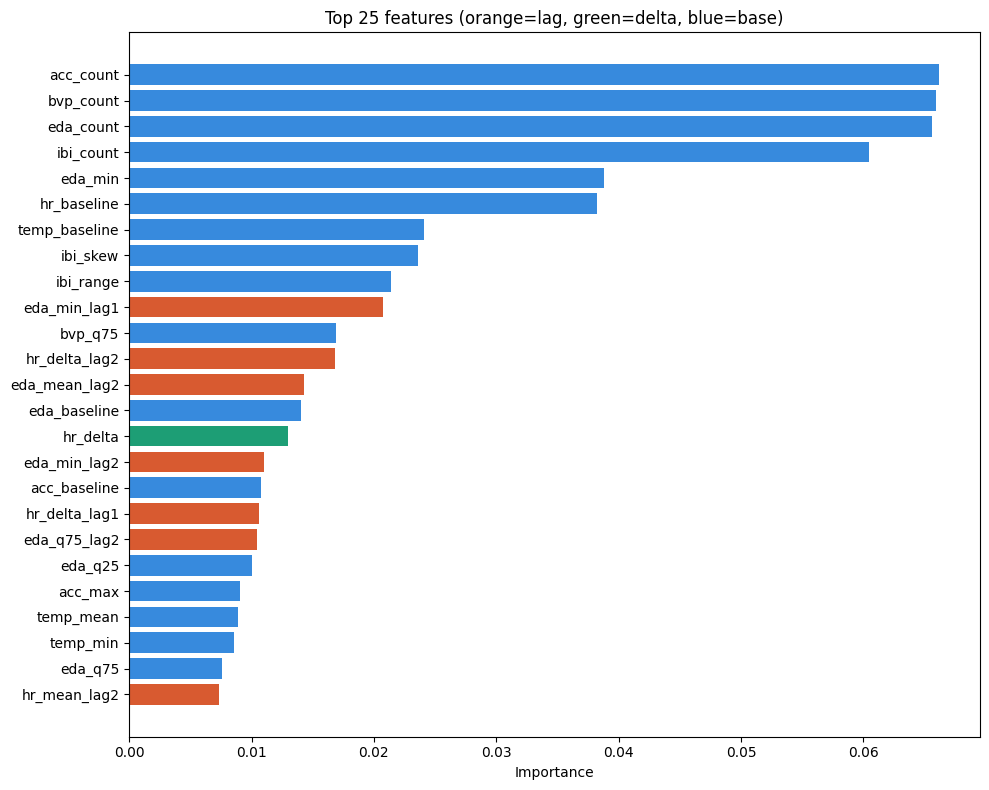

In [12]:
# Fit a fast RF just to rank features, then keep top 60
# This removes noise features that hurt on our small dataset

X_sel = train_norm[feat_cols].values
y_sel = train_norm['arousal'].values.astype(float)

rf_sel = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_sel.fit(X_sel, y_sel)

imp_df = pd.DataFrame({'feature': feat_cols,
                        'importance': rf_sel.feature_importances_,
                        'type': ['lag' if '_lag' in c else 'delta' if '_delta' in c else 'base'
                                 for c in feat_cols]
                       }).sort_values('importance', ascending=False)

N_KEEP = 60
top_features = imp_df.head(N_KEEP)['feature'].tolist()
# ensure indicators are included
for ind in indicator_cols:
    if ind not in top_features and ind in feat_cols:
        top_features.append(ind)

print(f'Selected {len(top_features)} features')
lag_kept   = [f for f in top_features if '_lag' in f]
delta_kept = [f for f in top_features if '_delta' in f]
print(f'Lag features in top {N_KEEP}: {len(lag_kept)}')
print(f'Delta features in top {N_KEEP}: {len(delta_kept)}')

print('\nTop 25 features:')
print(imp_df.head(25)[['feature','importance','type']].to_string(index=False))

# Plot
top25 = imp_df.head(25)
colors = ['#D85A30' if t=='lag' else '#1D9E75' if t=='delta' else '#378ADD' for t in top25['type']]
fig, ax = plt.subplots(figsize=(10,8))
ax.barh(top25['feature'][::-1], top25['importance'][::-1], color=colors[::-1])
ax.set_title('Top 25 features (orange=lag, green=delta, blue=base)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('importance_v4.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. ADASYN Oversampling

In [13]:
X_train = train_norm[top_features].values
y_train = train_norm['arousal'].values

unique, counts = np.unique(y_train, return_counts=True)
print('Before resampling:')
for u, c in zip(unique, counts): print(f'  Class {u}: {c}')

target = {cls: max(cnt, 150) for cls, cnt in zip(unique.astype(int), counts)}
try:
    res = ADASYN(sampling_strategy=target, n_neighbors=min(4, min(counts)-1), random_state=42)
    X_res, y_res = res.fit_resample(X_train, y_train)
    print('ADASYN succeeded.')
except Exception as e:
    print(f'ADASYN failed ({e}), using SMOTE...')
    res = SMOTE(sampling_strategy=target, k_neighbors=min(3, min(counts)-1), random_state=42)
    X_res, y_res = res.fit_resample(X_train, y_train)

print('After resampling:')
u2, c2 = np.unique(y_res, return_counts=True)
for u, c in zip(u2, c2): print(f'  Class {u}: {c}')
print(f'Total: {len(X_res)}')

# Class weights — 2× boost for extremes (classes 1 and 5)
class_counts_res = dict(zip(*np.unique(y_res, return_counts=True)))
total_res = len(y_res)
class_weights = {cls: total_res/(len(class_counts_res)*cnt) for cls,cnt in class_counts_res.items()}
class_weights[1] = class_weights[1] * 2.0
class_weights[5] = class_weights[5] * 2.0
sample_weights = np.array([class_weights[y] for y in y_res])
print('\nClass weights:')
for k,v in sorted(class_weights.items()): print(f'  Class {k}: {v:.3f}')

Before resampling:
  Class 1: 52
  Class 2: 399
  Class 3: 515
  Class 4: 320
  Class 5: 68
ADASYN succeeded.
After resampling:
  Class 1: 161
  Class 2: 399
  Class 3: 515
  Class 4: 320
  Class 5: 146
Total: 1541

Class weights:
  Class 1: 3.829
  Class 2: 0.772
  Class 3: 0.598
  Class 4: 0.963
  Class 5: 4.222


## 10. Leave-One-Pid-Out CV

In [14]:
def ordinal_clip(pred):
    return np.clip(np.round(pred), 1, 5).astype(int)

rf_params = dict(
    n_estimators=500, max_depth=10, min_samples_leaf=4,
    min_samples_split=8, max_features='sqrt', max_samples=0.8,
    random_state=42, n_jobs=-1
)
lgb_params = dict(
    objective='regression_l1', metric='mae',
    n_estimators=400, learning_rate=0.04, num_leaves=31, max_depth=5,
    min_child_samples=20, subsample=0.75, colsample_bytree=0.75,
    reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1
)

pids = train_norm['pid'].unique()
lopo_maes = {'rf': [], 'lgb': [], 'ens': []}
lopo_pid_results = []

print(f'LOPO CV ({len(pids)} folds)...\n')

for held_pid in pids:
    mask_val = train_norm['pid'] == held_pid
    mask_tr  = ~mask_val
    X_tr  = train_norm.loc[mask_tr,  top_features].values
    y_tr  = train_norm.loc[mask_tr,  'arousal'].values.astype(float)
    X_val = train_norm.loc[mask_val, top_features].values
    y_val = train_norm.loc[mask_val, 'arousal'].values

    u_tr, c_tr = np.unique(y_tr, return_counts=True)
    fold_target = {cls: max(cnt, 100) for cls,cnt in zip(u_tr.astype(int), c_tr)}
    safe_k = max(1, min(3, min(c_tr)-1))
    try:
        rf = ADASYN(sampling_strategy=fold_target, n_neighbors=safe_k, random_state=42)
        X_tr_s, y_tr_s = rf.fit_resample(X_tr, y_tr)
    except:
        sm = SMOTE(sampling_strategy=fold_target, k_neighbors=safe_k, random_state=42)
        X_tr_s, y_tr_s = sm.fit_resample(X_tr, y_tr)

    sw = np.array([class_weights.get(int(y), 1.0) for y in y_tr_s])

    m_rf = RandomForestRegressor(**rf_params)
    m_rf.fit(X_tr_s, y_tr_s, sample_weight=sw)
    p_rf_raw = m_rf.predict(X_val)

    m_lgb = lgb.LGBMRegressor(**lgb_params)
    m_lgb.fit(X_tr_s, y_tr_s, sample_weight=sw)
    p_lgb_raw = m_lgb.predict(X_val)

    # Determine best per-fold weights dynamically
    best_w, best_mae = 0.6, float('inf')
    for w in [0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
        p_try = ordinal_clip(w*p_rf_raw + (1-w)*p_lgb_raw)
        m = mean_absolute_error(y_val, p_try)
        if m < best_mae:
            best_mae = m; best_w = w

    p_rf  = ordinal_clip(p_rf_raw)
    p_lgb = ordinal_clip(p_lgb_raw)
    p_ens = ordinal_clip(best_w*p_rf_raw + (1-best_w)*p_lgb_raw)

    mae_rf  = mean_absolute_error(y_val, p_rf)
    mae_lgb = mean_absolute_error(y_val, p_lgb)
    mae_ens = mean_absolute_error(y_val, p_ens)

    lopo_maes['rf'].append(mae_rf)
    lopo_maes['lgb'].append(mae_lgb)
    lopo_maes['ens'].append(mae_ens)
    lopo_pid_results.append({'pid': held_pid, 'n': mask_val.sum(),
                              'rf': mae_rf, 'lgb': mae_lgb, 'ens': mae_ens,
                              'best_w_rf': best_w})

    print(f'  [{held_pid}] RF={mae_rf:.4f} LGB={mae_lgb:.4f} ENS={mae_ens:.4f} (w_RF={best_w:.1f})')

print()
for name, maes in lopo_maes.items():
    print(f'{name.upper():6s} LOPO MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}')

print('\nComparison to v3:')
print(f'  v3 RF  LOPO: 0.8465  |  v4 RF  LOPO: {np.mean(lopo_maes["rf"]):.4f}  {"+" if np.mean(lopo_maes["rf"])<0.8465 else "-"} improvement')
print(f'  v3 ENS LOPO: 0.8848  |  v4 ENS LOPO: {np.mean(lopo_maes["ens"]):.4f}  {"+" if np.mean(lopo_maes["ens"])<0.8848 else "-"} improvement')

LOPO CV (11 folds)...

  [01Z2] RF=0.9083 LGB=1.1750 ENS=0.9083 (w_RF=1.0)
  [70N8] RF=0.4496 LGB=0.5659 ENS=0.4496 (w_RF=0.8)
  [7PF3] RF=0.8333 LGB=0.9375 ENS=0.7778 (w_RF=0.5)
  [CQ2G] RF=1.0744 LGB=1.3140 ENS=1.0744 (w_RF=1.0)
  [D1XP] RF=0.2183 LGB=0.5211 ENS=0.2183 (w_RF=1.0)
  [DT5C] RF=0.9590 LGB=1.1066 ENS=0.9590 (w_RF=0.8)
  [F1ZM] RF=0.8148 LGB=0.9444 ENS=0.8148 (w_RF=1.0)
  [LIUY] RF=1.3306 LGB=1.2984 ENS=1.3306 (w_RF=0.8)
  [SE4Q] RF=0.6475 LGB=0.7623 ENS=0.6475 (w_RF=1.0)
  [TPQI] RF=0.7692 LGB=0.7363 ENS=0.7363 (w_RF=0.4)
  [Y21H] RF=0.8855 LGB=1.0382 ENS=0.8855 (w_RF=1.0)

RF     LOPO MAE: 0.8082 ± 0.2840
LGB    LOPO MAE: 0.9454 ± 0.2610
ENS    LOPO MAE: 0.8002 ± 0.2845

Comparison to v3:
  v3 RF  LOPO: 0.8465  |  v4 RF  LOPO: 0.8082  + improvement
  v3 ENS LOPO: 0.8848  |  v4 ENS LOPO: 0.8002  + improvement


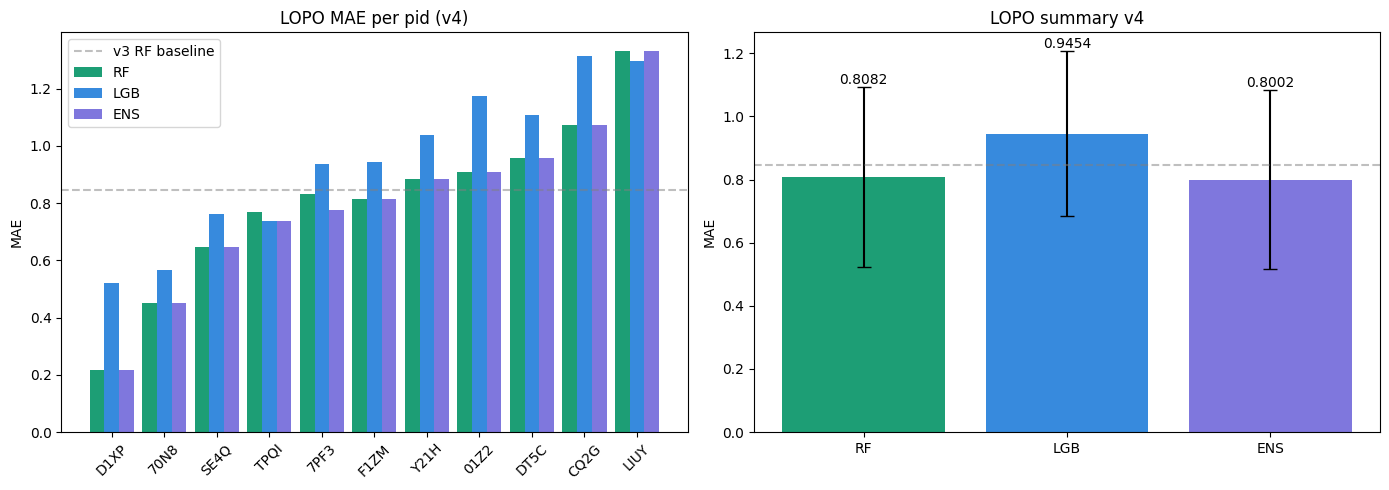

In [15]:
# Plot LOPO results
lopo_df = pd.DataFrame(lopo_pid_results).sort_values('ens')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(lopo_df)); w = 0.28
axes[0].bar(x-w, lopo_df['rf'],  w, label='RF',  color='#1D9E75')
axes[0].bar(x,   lopo_df['lgb'], w, label='LGB', color='#378ADD')
axes[0].bar(x+w, lopo_df['ens'], w, label='ENS', color='#7F77DD')
axes[0].axhline(0.8465, color='gray', ls='--', alpha=0.5, label='v3 RF baseline')
axes[0].set_xticks(x); axes[0].set_xticklabels(lopo_df['pid'], rotation=45)
axes[0].set_ylabel('MAE'); axes[0].set_title('LOPO MAE per pid (v4)'); axes[0].legend()

names = ['RF','LGB','ENS']
means = [np.mean(lopo_maes[k]) for k in ['rf','lgb','ens']]
stds  = [np.std(lopo_maes[k])  for k in ['rf','lgb','ens']]
axes[1].bar(names, means, yerr=stds, color=['#1D9E75','#378ADD','#7F77DD'], capsize=5)
axes[1].axhline(0.8465, color='gray', ls='--', alpha=0.5)
axes[1].set_ylabel('MAE'); axes[1].set_title('LOPO summary v4')
for i,(m,s) in enumerate(zip(means,stds)): axes[1].text(i, m+s+0.01, f'{m:.4f}', ha='center')
plt.tight_layout(); plt.savefig('lopo_v4.png', dpi=100, bbox_inches='tight'); plt.show()

## 11. Final Training + Prediction

In [16]:
print('Training final models...')

rf_final = RandomForestRegressor(**rf_params)
rf_final.fit(X_res, y_res.astype(float), sample_weight=sample_weights)
print('  RF done.')

lgb_final = lgb.LGBMRegressor(**lgb_params)
lgb_final.fit(X_res, y_res.astype(float), sample_weight=sample_weights)
print('  LGB done.')

# Use LOPO-determined weights
inv = np.array([1/np.mean(lopo_maes['rf']), 1/np.mean(lopo_maes['lgb'])])
w_rf, w_lgb = inv / inv.sum()
print(f'\nFinal weights: RF={w_rf:.3f}, LGB={w_lgb:.3f}')

# Train sanity
p_train = ordinal_clip(w_rf*rf_final.predict(X_train) + w_lgb*lgb_final.predict(X_train))
print(f'Train MAE: {mean_absolute_error(y_train, p_train):.4f}')

# Test predictions
X_test = test_norm[top_features].values
raw_rf  = rf_final.predict(X_test)
raw_lgb = lgb_final.predict(X_test)
raw_ens = w_rf * raw_rf + w_lgb * raw_lgb

# Rank-based calibration
train_y_float   = train_norm['arousal'].values.astype(float)
train_q = np.percentile(train_y_float, np.linspace(0, 100, 1000))
pred_q  = np.percentile(raw_ens,       np.linspace(0, 100, 1000))
calib_fn = interp1d(pred_q, train_q, bounds_error=False,
                     fill_value=(train_q[0], train_q[-1]))
pred_classes = ordinal_clip(calib_fn(raw_ens))

print('\nPrediction distribution (after calibration):')
u, c = np.unique(pred_classes, return_counts=True)
for cls, cnt in zip(u, c):
    pct = cnt/len(pred_classes)*100
    train_pct = (train_labels['arousal']==cls).mean()*100
    print(f'  Class {cls}: {cnt:4d} ({pct:.1f}%) | Train {train_pct:.1f}% | Δ={pct-train_pct:+.1f}%')

Training final models...
  RF done.
  LGB done.

Final weights: RF=0.539, LGB=0.461
Train MAE: 0.2939

Prediction distribution (after calibration):
  Class 1:   57 (3.8%) | Train 3.8% | Δ=+0.0%
  Class 2:  442 (29.5%) | Train 29.5% | Δ=+0.0%
  Class 3:  568 (38.0%) | Train 38.0% | Δ=-0.1%
  Class 4:  355 (23.7%) | Train 23.7% | Δ=+0.0%
  Class 5:   74 (4.9%) | Train 4.9% | Δ=+0.0%


## 12. Generate Submission

Final distribution:
arousal
1     57
2    442
3    568
4    355
5     74
Name: count, dtype: int64

Saved: submission_v4.csv

=== v3 vs v4 Summary ===
v3 LB:       0.21437
v3 LOPO ENS: 0.8848  |  v4 ENS LOPO: 0.8002
v3 RF  LOPO: 0.8465  |  v4 RF  LOPO: 0.8082
v4 train MAE: 0.2939


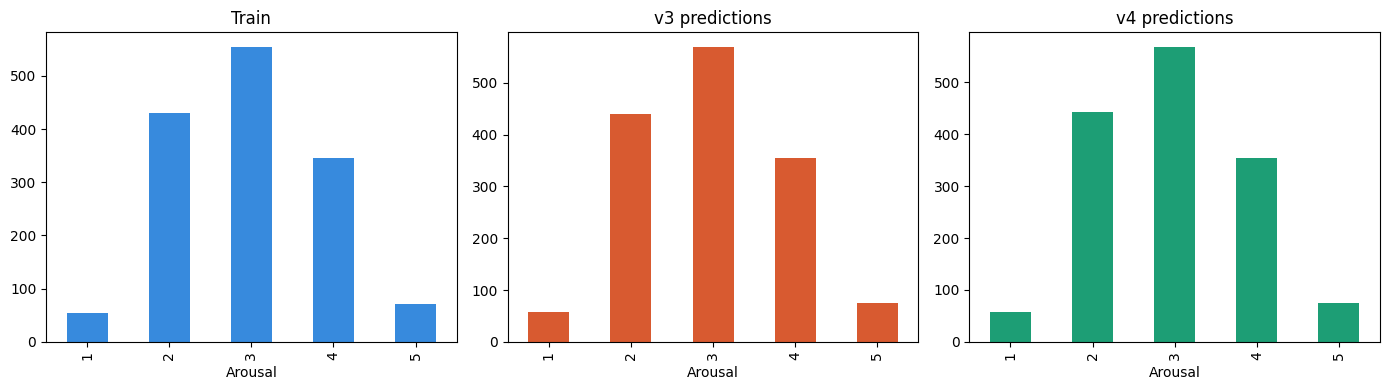

In [17]:
submission = pd.DataFrame({'id': test_labels['id'].values, 'arousal': pred_classes})
assert len(submission) == 1496
assert submission['arousal'].between(1,5).all()
assert (submission['id'] == test_labels['id']).all()

print('Final distribution:')
print(submission['arousal'].value_counts().sort_index())
submission.to_csv('submission_v4.csv', index=False)
print('\nSaved: submission_v4.csv')

print('\n=== v3 vs v4 Summary ===')
print(f'v3 LB:       0.21437')
print(f'v3 LOPO ENS: 0.8848  |  v4 ENS LOPO: {np.mean(lopo_maes["ens"]):.4f}')
print(f'v3 RF  LOPO: 0.8465  |  v4 RF  LOPO: {np.mean(lopo_maes["rf"]):.4f}')
print(f'v4 train MAE: {mean_absolute_error(y_train, p_train):.4f}')

# Compare distributions
v3_dist = {1:58, 2:440, 3:569, 4:354, 5:75}
fig, axes = plt.subplots(1,3,figsize=(14,4))
train_labels['arousal'].value_counts().sort_index().plot.bar(ax=axes[0], color='#378ADD')
axes[0].set_title('Train'); axes[0].set_xlabel('Arousal')
pd.Series(v3_dist).plot.bar(ax=axes[1], color='#D85A30')
axes[1].set_title('v3 predictions'); axes[1].set_xlabel('Arousal')
submission['arousal'].value_counts().sort_index().plot.bar(ax=axes[2], color='#1D9E75')
axes[2].set_title('v4 predictions'); axes[2].set_xlabel('Arousal')
plt.tight_layout(); plt.savefig('v3_vs_v4.png', dpi=100, bbox_inches='tight'); plt.show()